In [1]:
from lightkurve import DataCube, ErrorCube, DataFrame

%load_ext autoreload
%autoreload 2

In [2]:
from astropy.io import fits
import numpy as np
import pandas as pd

hdulist = fits.open(
    "./src/lightkurve/data/tess-s0001-4-2_84.291190_-80.469170_6x6_astrocut.fits"
)

# Prepare DataCube

In [3]:
flux_array = hdulist[1].data["FLUX"].astype(float)
flux_err_array = hdulist[1].data["FLUX_ERR"].astype(float)
time = hdulist[1].data["TIME"].astype(float)
time_corr = hdulist[1].data["TIMECORR"].astype(float)
c0, r0 = hdulist[1].header["1CRV4P"], hdulist[1].header["2CRV4P"]
row, col = np.arange(flux_array.shape[1]) + r0, np.arange(flux_array.shape[2]) + c0
aper = flux_array.mean(axis=0) > 10000
bkg_aper = flux_array.mean(axis=0) < 4000

time_mask = hdulist[1].data["QUALITY"] == 0

In [4]:
flux = DataCube(
    flux_array,
    time_indices={"btjd": time, "spacecraft_time": time - time_corr},
    row_indices={"pixel_row": row},
    col_indices={"pixel_column": col},
)

flux_err = ErrorCube(
    flux_err_array,
    time_indices={"btjd": time, "spacecraft_time": time - time_corr},
    row_indices={"pixel_row": row},
    col_indices={"pixel_column": col},
)

In [5]:
flux, flux_err

(📘 DataCube (50, 6, 6), 📕 ErrorCube (50, 6, 6))

In [6]:
flux

pixel_column,1628,1629,1630,1631,1632,1633
pixel_row,,,,,,
257,972.539368,965.366943,938.845215,1154.414795,1616.280029,2285.411133
258,2091.041260,2403.761475,42657.632812,65179.886719,8305.186523,7378.595703
259,4117.913574,6243.910156,100720.773438,101675.906250,42470.730469,8941.966797
260,5998.216797,29425.457031,102240.070312,103746.945312,61337.554688,7088.634766
261,4179.137207,26175.996094,103074.070312,105171.984375,40686.078125,4181.030273
262,3493.345703,11072.824219,102138.585938,104423.625000,10715.317383,3497.708008


In [7]:
flux_err

pixel_column,1628,1629,1630,1631,1632,1633
pixel_row,,,,,,
257,0.876119,0.868199,0.852017,0.945679,1.120531,1.321546
258,1.265783,1.356540,5.598882,6.952911,2.503161,2.350773
259,1.763391,2.166304,8.639107,8.677429,5.671174,2.576680
260,2.113300,4.675353,8.696113,8.800759,6.741338,2.305950
261,1.774688,4.403429,8.761114,8.907879,5.498235,1.769044
262,1.621295,2.873620,8.711569,8.847847,2.836913,1.626671


# Tests

## Downsample

In [345]:
flux.downsample(5)

pixel_column,1628,1629,1630,1631,1632,1633
pixel_row,,,,,,
257,4954.178406,4925.318787,4791.271667,5874.457397,8181.752197,11542.473877
258,10546.189941,12140.599854,212464.808594,330794.289062,41869.373047,37157.149414
259,20676.282227,31378.806152,503532.476562,508472.515625,213639.437500,45084.606445
260,29959.413574,146581.812500,511157.242188,518727.242188,308867.285156,35736.653320
261,20870.504883,128995.683594,515297.992188,525822.875000,205362.949219,21042.489746
262,17467.682129,54943.779297,510592.140625,522081.343750,53832.016602,17597.307861


In [61]:
flux_err.downsample(5)

pixel_column,1628,1629,1630,1631,1632,1633
pixel_row,,,,,,
257,1.975846,1.960811,1.923969,2.132164,2.521087,2.970033
258,2.841791,3.048587,12.495206,15.663314,5.620483,5.275358
259,3.951065,4.856458,19.316367,19.404992,12.719380,5.785646
260,4.722697,10.435037,19.444074,19.678958,15.127453,5.177599
261,3.965818,9.775275,19.589177,19.917959,12.352569,3.968441
262,3.625005,6.401292,19.477877,19.783728,6.358706,3.648632


## Imposing an aperture mask where `mean`(flux of pixel) > 10,000

In [ ]:
flux[:, aper]

## Sum of flux in aperture, per cadence

In [ ]:
flux[:, aper].sum(axis=1)

## Sum of flux error in aperture, per cadence. 

In [ ]:
flux_err[:, aper].sum(axis=1)

# Check types when transformed

In [ ]:
type(flux), type(flux_err)

In [ ]:
type(flux[:, aper]), type(flux_err[:, aper])

In [ ]:
type(flux[:, 0, :]), type(flux_err[:, 0, :])
type(flux[:, :, 0]), type(flux_err[:, :, 0])

In [ ]:
type(flux[:, 0, 0]), type(flux_err[:, 0, 0])

In [ ]:
type(flux[:, aper].sum(axis=0)), type(flux_err[:, aper].sum(axis=0))
type(flux[:, aper].sum(axis=1)), type(flux_err[:, aper].sum(axis=1))

# Plot the light curve

In [ ]:
import matplotlib.pyplot as plt

time = np.asarray(flux.btjd)
bkg = flux[:, bkg_aper].mean(axis=1)
bkg_err = flux_err[:, bkg_aper].mean(axis=1)

bkg -= bkg.median()

lc = flux[:, aper].sum(axis=1)
lc_err = flux_err[:, aper].sum(axis=1)

plt.figure()
plt.title("Raw")
plt.errorbar(time, lc.values, lc_err.values, ls="", marker=".", c="k")
# plt.ylim(.88e6, .94e6)

lc = flux[:, aper].sum(axis=1) - (bkg * aper.sum())
lc_err = flux_err[:, aper].sum(axis=1) + (bkg_err * aper.sum())

plt.figure()
plt.title("Background Subtracted")
plt.errorbar(time, lc.values, lc_err.values, ls="", marker=".", c="k")
# plt.ylim(0.88e6, 0.94e6)

## Info

repo: https://github.com/tessgi/secret/tree/christina-sketch1/src/lightkurve

# Milestones;

- ✅ Break the Cube, Frame, and Series classes into their own modules (cube.py, frame.py, series.py)
- ✅ Convert these demo functions into tests inside the package to fully test the functionality as users of lightkurve would need it. As you find any tests (breaking or passing) that cover functionality users need, add them to the tests.
    - ✅ To do this you will need to choose a reasonable piece of test data we can ship with the package. Crucially this must be small (ideally kb). You can trim down some tesscut data using lightkurve to add to the package
    - ✅ Confirm adjusted data product is appropriate and sufficient for tests
    - ✅ Trim to 50 frames
    - ✅ Put in tests/data
- ✅ Take a look at the pandas documentation and see if we can safely quiet the user warning that we have for adding our convenience functions (e.g. `flux.cadence`)
    - 🗒️ Add convenience functions to _metadata namespace
    - ❗️ Don't add existing attributes to this namespace, it messes up pandas at the core level somehow
- Currently there is an aggregate method for time. Create a similar aggregate method that will instead aggregate on columns so that;
    - ✅ DataCube.spatial_aggregate(...) -> returns a lower resolution datacube. e.g. sums pixels in row and column direction to create a lower resolution image
    - ✅ DataFrame.spatial_aggregate(...) -> returns a lower resolution dataframe
    - ✅ DataSeries has no spatial axis to aggregate
    - Create functions for ErrorCube and ErrorFrame
    - ✅ downsample methods more similar to time downsample
    - Think about binning to specific time/space points
- ✅ Tests for ErrorCubes
- Documentation
- ✅ Cube `__repr__`
- Consider bleed columns, can these be accounted for easily in the DataCube framework?

- We'll come back to; can we have in lightkurve3 a way to take cubes, frames, series and convert to fits imagehdu, tablehdu, and columnhdu.

- See what happens if I give too many rows and columns
- Change header -> "meta" or something like that
- meta could return a dataclass that is indexable, could hold relevant fits file information when loaded in
- Folding - add index. Return a new object (deepcopy) unless inplace=True
- Check downsample error
- Think about how lightkurve will interact with these objects
- Think about data quality handling
- 

## Smaller test data

In [ ]:
from lksearch import TESSSearch
from astropy.coordinates import SkyCoord

search_input = (84.291190, -80.469170)
search_input = SkyCoord(*search_input, unit="deg", frame="icrs")
search_result = TESSSearch(search_input, hlsp=False)

# You can filter two different ways to get the same result.
# search_result.filter_table(pipeline='TESScut')
downloads_table = search_result.tesscut.filter_table(sector=1).download(TESScut_size=6)
hdulist = fits.open(downloads_table["Local Path"][0])

In [ ]:
hdulist = fits.open(
    "/Users/dkgiles/.lksearch/cache/mastDownload/TESSCut/tess-s0001-4-2_84.291190_-80.469170_6x6_astrocut.fits"
)

In [ ]:
hdulist[1].data = hdulist[1].data[:50]

In [ ]:
hdulist.writeto(
    "./src/lightkurve/data/tess-s0001-4-2_84.291190_-80.469170_6x6_astrocut.fits",
)

## Spatial aggregation

In [ ]:
flux

In [ ]:
flux_lowres = flux.spatial_aggregate(3, 3)
flux_lowres

#### change to 
`flux_lowres = flux.spatial_aggregate(factor=int)`

In [ ]:
flux_lowres = flux.spatial_aggregate(4, 4)
flux_lowres

In [ ]:
def single_cadence_frame(datacube, cadence):
    return DataFrame(
        datacube.to_array()[cadence],
        index=datacube.row[:: datacube.nrow],
        columns=datacube.column[: datacube.ncol],
    )

In [ ]:
single_cadence_frame(flux_lowres, 0)

In [ ]:
flux.downsample?

In [ ]:
flux.downsample(5)

In [ ]:
df0 = single_cadence_frame(flux, 0)
df0

In [ ]:
print(f"Sum of first 2x2: {df0.iloc[:2, :2].sum().sum()}")
df0.iloc[:2, :2]

In [ ]:
df0.spatial_aggregate(3, 3)

### Spatial downsampling like the time downsampling

In [ ]:
flux.spatial_downsample(2)

In [ ]:
flux.spatial_downsample((2, 3))

In [ ]:
row = flux.pixel_row

In [ ]:
dr = np.median(np.diff(np.sort(np.unique(row)))) * 3
bins_row = np.arange(row.min(), row.max() + dr, dr)

In [ ]:
bins_row

In [ ]:
bin_edges_left_row = pd.cut(np.sort(row), bins_row, right=False)

In [ ]:
bin_edges_left_row

In [ ]:
flux.sum().sum()

In [ ]:
flux.spatial_downsample(2).sum().sum()

In [ ]:
flux[:, :-1].spatial_downsample(2)

In [ ]:
flux[:, :-2].sum().sum()

In [ ]:
flux[:, :-1].spatial_downsample(2).sum().sum()

In [ ]:
flux[:, :, :-1].spatial_downsample(2)

In [ ]:
flux[:, :, :-2].sum().sum()

In [ ]:
flux[:, :, :-1].spatial_downsample(2).sum().sum()

In [ ]:
flux.spatial_downsample(2).to_array()[0]

In [ ]:
def single_cadence_frame(datacube, cadence):
    indices = [f"{i[0]} {i[1]}" for i in zip(datacube.index.names, datacube.index[0])]
    str_index = "; ".join(indices)
    return pd.DataFrame(
        datacube.to_array()[cadence],
        index=pd.Series(datacube.row[:: datacube.nrow], name="row"),
        columns=pd.Series(datacube.column[: datacube.ncol], name="column"),
    ).style.set_caption(str_index)

In [ ]:
f0 = single_cadence_frame(flux, 0)
f0

In [ ]:
f0.style.set_caption("name")

In [ ]:
f0.index.name = "row"

In [ ]:
f0.columns.name = "column"

In [ ]:
f0

In [ ]:
[f"{i[0]}, {i[1]}" for i in zip(flux.index.names, flux.index[0])]

In [ ]:
flux.to_dataframe(0, 0)

In [ ]:
flux.index[0]

In [ ]:
c = 0

In [ ]:
with np.printoptions(edgeitems=2, threshold=5):
    print(flux)
    for c in [0, -1]:
        indices = [
            (flux.index.names[i], flux.index[c][i])
            for i in range(len(flux.index.names))
        ]
        print(f"""{indices}\n{flux.to_array()[c]}\n...""")

In [ ]:
with pd.option_context("display.max_columns", 4):
    print(flux)
    for c in [0, -1]:
        indices = [
            (flux.index.names[i], flux.index[c][i])
            for i in range(len(flux.index.names))
        ]
        print(f"""{indices}\n{single_cadence_frame(flux, c)}\n...""")

In [ ]:
pd.set_option("display.max.columns", 4)

In [ ]:
print(repr(single_cadence_frame(flux, 0)))

In [ ]:
print(flux._repr_html_())

# Dummy data

In [375]:
ntime, nrow, ncol = 200, 10, 14
test_data = np.ones((ntime, nrow, ncol))
row, col = np.arange(test_data.shape[1]), np.arange(test_data.shape[2])
df = DataCube(test_data, row_indices={"row": row}, col_indices={"column": col})
df_err = ErrorCube(test_data, row_indices={"row": row}, col_indices={"column": col})

In [376]:
df, df_err

(📘 DataCube (200, 10, 14), 📕 ErrorCube (200, 10, 14))

In [65]:
df.info()

<class 'lightkurve.datacube.DataCube'>
MultiIndex: 200 entries, (0,) to (199,)
Columns: 140 entries, (0, 0, 0) to (139, 9, 13)
dtypes: float64(140)
memory usage: 228.9 KB


In [370]:
df

column,0,1,2,3,4,5,6,7,8,9,...
row,,,,,,,,,,,
0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...
1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...
2,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...
3,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...
4,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...
5,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...
6,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...
7,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...
8,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...


In [372]:
df.fold(3)
# fix this

IndexError: Too many levels: Index has only 1 levels, not 2

In [67]:
df_err

column,0,1,2,3,4,5,6,7,8,9,...
row,,,,,,,,,,,
0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...
1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...
2,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...
3,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...
4,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...
5,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...
6,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...
7,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...
8,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...


In [377]:
new_index = df.index.to_frame()
new_index["time"] = new_index["cadence"] / 100
new_index = new_index.set_index("time", append=True)

In [381]:
df.index = new_index.index

In [156]:
df.index.get_level_values(-1)[2]

0.02

In [429]:
df.downsample(2, level=-1)

column,0,1,2,3,4,5,6,7,8,9,...
row,,,,,,,,,,,
0,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...
1,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...
2,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...
3,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...
4,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...
5,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...
6,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...
7,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...
8,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...


In [320]:
nframes = 2
index = df.index.get_level_values(-1)
# Find the average spacing of the index
dt = np.median(np.diff(index)) * nframes
nbins = int(np.ceil((index.max() - index.min()) / dt) + 1)
# Calculate what bin edges result in this spacing
bins = np.arange(index.min(), index.min() + nbins * dt, dt)
bin_edges_left = pd.cut(
    np.sort(index), bins.round(16), right=False, include_lowest=True
)
# bin_edges_right = pd.cut(np.sort(index), bins, right=True)
# groupby these bin edges

gb = df.groupby(bin_edges_left, observed=False)

new = gb.sum()
# We only accept cases where the number of points in a bin is the same as the number of frames we downsample to
count = gb[int(df.columns.get_level_values(0)[0])].count()

In [255]:
arr = np.arange(0.0, 2.0, 0.01)
bins = np.linspace(0.0, 2.0, 101)
pd.cut(arr[:5], bins, right=False, include_lowest=True)

[[0.0, 0.02), [0.0, 0.02), [0.02, 0.04), [0.02, 0.04), [0.04, 0.06)]
Categories (100, interval[float64, left]): [[0.0, 0.02) < [0.02, 0.04) < [0.04, 0.06) < [0.06, 0.08) ... [1.92, 1.94) < [1.94, 1.96) < [1.96, 1.98) < [1.98, 2.0)]

In [ ]:
(df.downsample(2).to_array() == 2).all()

In [ ]:
(df.spatial_downsample(3) == 9).all().all()

In [76]:
df.spatial_downsample((1, 2))

column,0,2,4,6,8,10,12
row,,,,,,,
0,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
1,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
2,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
3,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
4,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
5,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
6,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
7,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
8,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


In [73]:
df.spatial_downsample((5, 7))

column,0,7
row,,
0,35.000000,35.000000
5,35.000000,35.000000


In [74]:
df.spatial_downsample(3)

column,0,3,6,9
row,,,,
0,9.000000,9.000000,9.000000,9.000000
3,9.000000,9.000000,9.000000,9.000000
6,9.000000,9.000000,9.000000,9.000000


In [ ]:
df_err.spatial_downsample(3)

In [ ]:
(df.downsample(3).to_array() == 3).all()

In [ ]:
(df.spatial_aggregate(5, 7).to_array().round() == 4).all()

In [ ]:
(df.spatial_downsample(2).to_array() == 4).all()

In [ ]:
(
    df[:, :, :-1].spatial_downsample(2).to_array()
    == df[:, :, :-2].spatial_downsample(2).to_array()
).all()

In [ ]:
(df_err.downsample(4).to_array() == 2).all()

In [ ]:
(df_err.downsample(9).to_array() == 3).all()

In [ ]:
(df_err.to_array()[0][0] ** 2).sum()

In [ ]:
df_err

In [ ]:
df_err.spatial_aggregate(5, 7)

In [ ]:
assert (df_err.spatial_aggregate(5, 7).to_array().round() == 2).all()

In [ ]:
flux[:, [1, 2, 3], [1, 2, 3]]

# Folding

In [364]:
flux

pixel_column,1628,1629,1630,1631,1632,1633
pixel_row,,,,,,
257,972.539368,965.366943,938.845215,1154.414795,1616.280029,2285.411133
258,2091.041260,2403.761475,42657.632812,65179.886719,8305.186523,7378.595703
259,4117.913574,6243.910156,100720.773438,101675.906250,42470.730469,8941.966797
260,5998.216797,29425.457031,102240.070312,103746.945312,61337.554688,7088.634766
261,4179.137207,26175.996094,103074.070312,105171.984375,40686.078125,4181.030273
262,3493.345703,11072.824219,102138.585938,104423.625000,10715.317383,3497.708008


In [367]:
df

column,0,1,2,3,4,5,6,7,8,9,...
row,,,,,,,,,,,
0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...
1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...
2,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...
3,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...
4,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...
5,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...
6,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...
7,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...
8,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...


In [365]:
folded = flux.fold(0.3)
folded

column,0,1,2,3,4,5
row,,,,,,
0,972.539368,965.366943,938.845215,1154.414795,1616.280029,2285.411133
1,2091.041260,2403.761475,42657.632812,65179.886719,8305.186523,7378.595703
2,4117.913574,6243.910156,100720.773438,101675.906250,42470.730469,8941.966797
3,5998.216797,29425.457031,102240.070312,103746.945312,61337.554688,7088.634766
4,4179.137207,26175.996094,103074.070312,105171.984375,40686.078125,4181.030273
5,3493.345703,11072.824219,102138.585938,104423.625000,10715.317383,3497.708008


In [366]:
folded[:10, 0, :]

,,,series,0,1,2,3,4,5
,,,row,0,0,0,0,0,0
,,,column,0,1,2,3,4,5
cadence,btjd,spacecraft_time,phase,,,,,,
0,1325.324261,1325.323506,0.000000,972.539368,965.366943,938.845215,1154.414795,1616.280029,2285.411133
1,1325.345094,1325.344340,0.069444,972.313477,966.041748,939.378052,1157.330811,1616.310791,2286.349365
2,1325.365927,1325.365173,0.138888,975.665710,967.891174,942.014038,1165.668457,1619.722168,2290.568604
3,1325.386761,1325.386006,0.208331,979.376587,972.970520,945.712402,1159.484375,1623.469971,2293.927002
4,1325.407594,1325.406840,0.277775,979.624390,973.837219,947.865112,1161.242310,1623.600952,2294.077637
5,1325.428427,1325.427673,0.347219,983.042419,978.066895,949.849365,1165.843384,1626.385376,2299.407715
6,1325.449260,1325.448506,0.416663,985.820435,980.250061,951.908569,1169.730103,1630.028198,2302.799072


## Convenient that it works... but unexpected dc$\rightarrow$df "conversion"

In [361]:
folded.sort_values(by="phase")

,,,series,0,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
,,,row,0,0,0,0,0,0,1,1,1,1,...,4,4,4,4,5,5,5,5,5,5
,,,column,0,1,2,3,4,5,0,1,2,3,...,2,3,4,5,0,1,2,3,4,5
cadence,btjd,spacecraft_time,phase,,,,,,,,,,,,,,,,,,,,,
0,1325.324261,1325.323506,0.000000,972.539368,965.366943,938.845215,1154.414795,1616.280029,2285.411133,2091.041260,2403.761475,42657.632812,65179.886719,...,103074.070312,105171.984375,40686.078125,4181.030273,3493.345703,11072.824219,102138.585938,104423.625000,10715.317383,3497.708008
29,1325.928422,1325.927673,0.013870,1022.008789,1017.371277,992.677368,1205.549805,1675.377930,2356.410889,2141.015869,2467.567871,43096.500000,68442.468750,...,103008.914062,105127.710938,41458.894531,4242.437012,3491.969971,10842.014648,102059.390625,104379.648438,10813.754883,3554.153809
15,1325.636758,1325.636006,0.041657,1008.499329,1003.342041,976.711731,1192.492676,1657.128418,2336.848145,2127.663574,2451.052246,42745.492188,67310.953125,...,103016.429688,105127.960938,41331.421875,4232.372070,3496.219482,10924.523438,102074.062500,104379.898438,10809.369141,3544.908203
44,1326.240920,1326.240173,0.055528,1024.433105,1017.674561,994.234192,1208.838623,1676.309937,2356.109131,2144.079590,2471.985596,42520.347656,68992.257812,...,102980.820312,105099.210938,41913.203125,4259.364258,3484.945557,10800.898438,102024.273438,104351.343750,10885.234375,3565.734375
1,1325.345094,1325.344340,0.069444,972.313477,966.041748,939.378052,1157.330811,1616.310791,2286.349365,2088.742188,2404.846924,42648.261719,65202.703125,...,103073.914062,105171.820312,40717.785156,4182.341797,3494.455322,11068.058594,102138.429688,104423.468750,10720.024414,3498.899414
30,1325.949255,1325.948506,0.083314,1020.777466,1014.113464,990.250000,1204.264282,1674.736206,2352.281738,2141.237793,2466.788330,42874.878906,68531.125000,...,103009.328125,105127.992188,41637.496094,4251.505371,3485.535645,10828.302734,102059.812500,104379.929688,10839.880859,3557.117432
16,1325.657591,1325.656839,0.111101,1009.213867,1004.830933,978.269958,1195.137451,1660.215332,2337.270508,2131.110107,2452.632812,42962.007812,67363.039062,...,103023.093750,105134.835938,41221.449219,4228.779297,3496.828369,10921.512695,102073.500000,104386.734375,10780.608398,3540.203369


In [350]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Phase (period = 0.3d)')

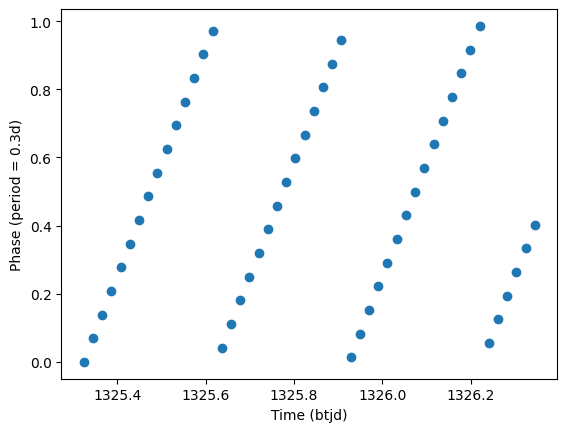

In [353]:
plt.scatter(folded.btjd, folded.phase)
plt.xlabel("Time (btjd)")
plt.ylabel("Phase (period = 0.3d)")

In [374]:
flux.fold(0.3, inplace=True)
flux

pixel_column,1628,1629,1630,1631,1632,1633
pixel_row,,,,,,
257,972.539368,965.366943,938.845215,1154.414795,1616.280029,2285.411133
258,2091.041260,2403.761475,42657.632812,65179.886719,8305.186523,7378.595703
259,4117.913574,6243.910156,100720.773438,101675.906250,42470.730469,8941.966797
260,5998.216797,29425.457031,102240.070312,103746.945312,61337.554688,7088.634766
261,4179.137207,26175.996094,103074.070312,105171.984375,40686.078125,4181.030273
262,3493.345703,11072.824219,102138.585938,104423.625000,10715.317383,3497.708008


In [355]:
flux.phase

Index([                 0.0,   0.0694437541771246,  0.13888751319958223,
         0.2083312768771369,   0.2777750452135782,  0.34721881801412263,
        0.41666259508550263,   0.4861063766164383,   0.5555501622203944,
         0.6249939517033454,   0.6944377452653802,    0.763881542704894,
         0.8333253438331667,   0.9027691486479247,   0.9722129569536264,
        0.04165676855852026,  0.11110058346184819,   0.1805444018599095,
         0.2499882231653222,  0.31943204757514354,  0.38887587489458997,
         0.4583197051266932,   0.5277635380736381,   0.5972073737369404,
         0.6666512121203899,   0.7360950528283563,   0.8055388962534381,
         0.8749827418112849,   0.9444265898899479, 0.013870440108955107,
        0.08331429246072738,   0.1527581469437489,  0.22220200336854162,
         0.2916458619253415,  0.36108972223140284,  0.43053358447847745,
        0.49997744866504956,   0.5694213144023101,   0.6388651818835267,
         0.7083090509199793,   0.7777529217034196, 